In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib 
import matplotlib.pyplot as plt
import numpy as np

from func_for_fig4 import *
import adaptive
adaptive.notebook_extension()


In [3]:
matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": False,
        # "font.family": "serif",
        # "font.serif": ["Times"],
    }
)
aps_figwidth = 6.6
aps_halfwidth = 3.375

In [5]:
from koala import pointsets
system_size = 10
sigma = 0.05
kappa_shift = 0.3
beta = 1.0

sites = pointsets.grid(system_size, system_size, system_size)

sites = pointsets.move_all_points(sites, sigma, kappa_shift, beta, resolution=10, verbose=True)

bond_distance = 1.3 / system_size

# bonds = bonds_func(sites, bond_distance)

# syst = amorph_3DTI(sites, bonds)


100%|██████████| 1000/1000 [00:26<00:00, 38.33it/s]


In [9]:
from mpi4py import MPI
# lattice params
system_size = 10

# sys params
A = 1
MJ = 2.3
onsite_disorder = 1
 
num_realizations = 1
seed = 0
bond_lengthscale = 1 / system_size
bond_power = 1 / system_size

# localizer params
kappa = 2
E0 = 0

# function
params_obs_3D(
    system_size=system_size,
    MJ=MJ,
    A=A,
    onsite_disorder=onsite_disorder,
    disorder_average=1,
    bond_lengthscale=bond_lengthscale,
    bond_power=bond_power,
    kappa_spec=kappa,
    E0=E0,
    sigma=0.05,
    kappa_shift=0.3,
    beta=1,
    provide_sites=False,
    resolution=10,
    # comm=MPI.COMM_SELF,

    )



np.float64(0.9999996943600995)

# 4a

In [10]:
# plot params
MJ_bounds = (0, 4)
disorder_bounds = (0, 10)
num_realizations = 2

def goal(l):
    # return l.loss() < 0.05  # continue until loss is small enough
    return l.npoints > 5000  # continue until 1000 points
n_task = 8

# adaptive
def f(dis_MJ):
    return params_obs_3D(
        system_size=system_size,
        MJ=dis_MJ[0],
        A=A,
        onsite_disorder=dis_MJ[1],
        disorder_average=num_realizations,
        bond_lengthscale=bond_lengthscale,
        bond_power=bond_power,
        kappa_spec=kappa,
        E0=E0,
        sigma=0.,
        kappa_shift=0,
        beta=1,
        provide_sites=False,
        )


learner_dis = adaptive.Learner2D(
    f,
    bounds=[
        MJ_bounds,
        disorder_bounds,
    ],
)

learner_dis.load("data_fig4a.pkl")
print(learner_dis.npoints)
# runner_dis = adaptive.Runner(
#     learner_dis,
#     goal=goal, 
#     ntasks=n_task,
# )

# runner_dis.live_info() 

5001


# 4b

In [11]:
system_size = 10
# plot params
MJ_bounds = (0, 4)
sigma_bounds = (0, .05 / system_size)

def goal(l):
    # return l.loss() < 0.05  # continue until loss is small enough
    return l.npoints > 5000  # continue until 1000 points
n_task = 8

# adaptive
f = lambda sigma_MJ: params_obs_3D(
    system_size=system_size,
    MJ=sigma_MJ[0],
    A=A,
    onsite_disorder=0,
    disorder_average=1,
    bond_lengthscale=bond_lengthscale,
    bond_power=bond_power,
    kappa_spec=kappa,
    E0=E0,
    sigma=sigma_MJ[1],
    kappa_shift=0,
    beta=1,
    )

learner_sigma = adaptive.Learner2D(
    f,
    bounds=[
        MJ_bounds,
        sigma_bounds,
    ],
)

learner_sigma.load("data_fig4b.pkl")
print(learner_sigma.npoints)
# runner_sigma = adaptive.Runner(
#     learner_sigma,
#     goal=goal,
#     ntasks=n_task,
# )

# runner_sigma.live_info()

4626


# 4c

In [9]:
# plot params
MJ_bounds = (0, 4)
sigma_bounds = (0, 2 / system_size)

def goal(l): 
    # return l.loss() < 0.05  # continue until loss is small enough
    return l.npoints > 5000  # continue until 1000 points
n_task = 8

# adaptive
f = lambda sigma_MJ: params_obs_3D(
    system_size=system_size,
    MJ=sigma_MJ[0],
    A=A,
    onsite_disorder=0,
    disorder_average=1,
    bond_lengthscale=bond_lengthscale,
    bond_power=bond_power,
    kappa_spec=kappa,
    E0=E0,
    sigma=sigma_MJ[1],
    kappa_shift=0,
    beta=1,
    provide_sites=False,
    )

learner_repulsion = adaptive.Learner2D(
    f,
    bounds=[
        MJ_bounds,
        sigma_bounds,
    ],
)

# learner_repulsion.load("data_fig4b.pkl")

# print(learner_repulsion.npoints)

runner_repulsion = adaptive.Runner(
    learner_repulsion,
    goal=goal,
    ntasks=n_task,
)

runner_repulsion.live_info()

# plot

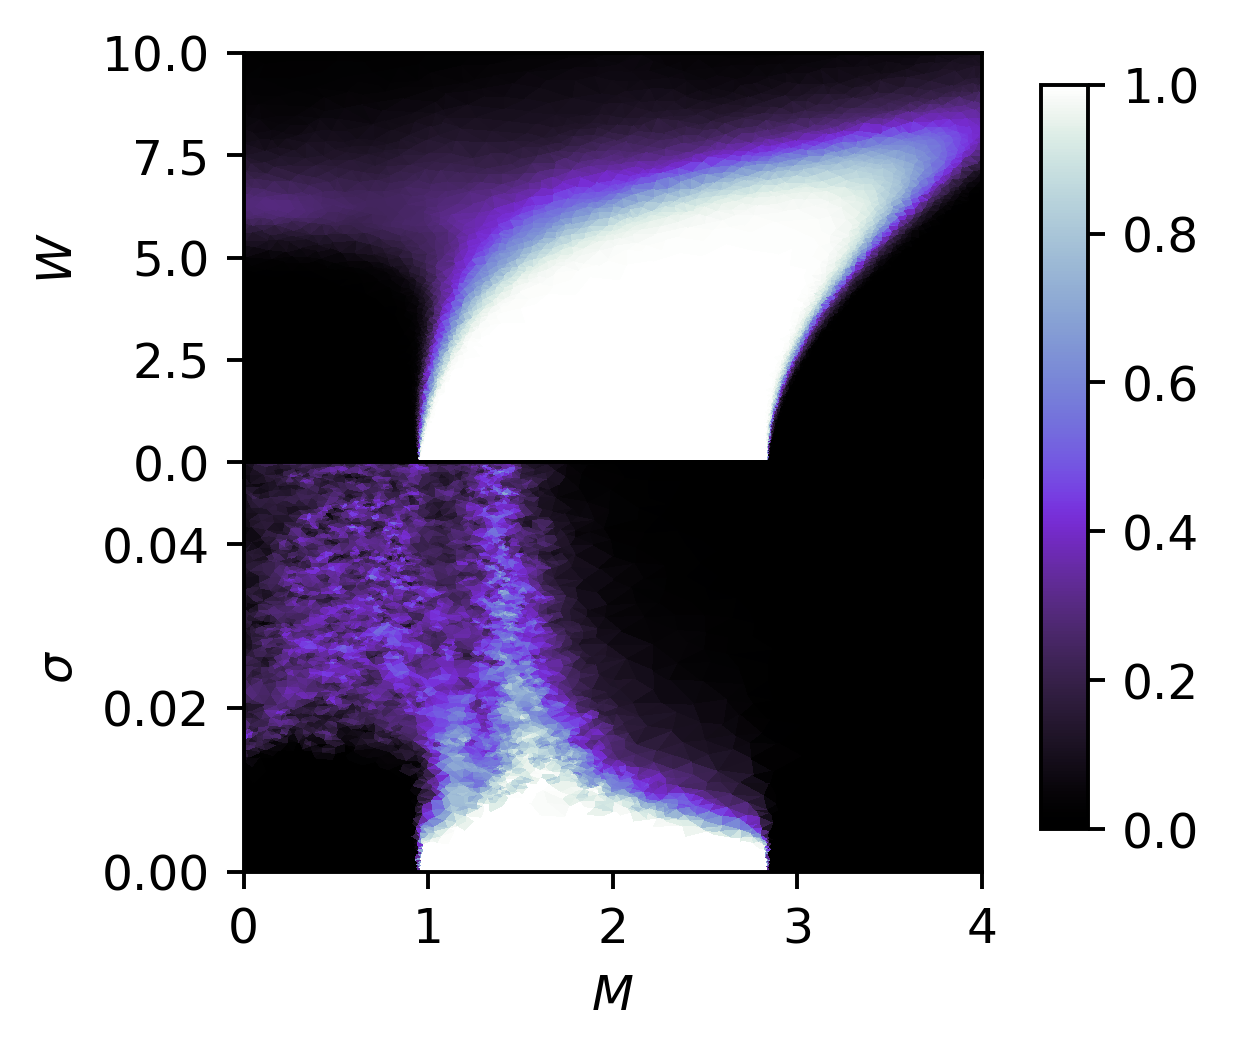

In [ ]:
specs = np.array([learner_dis.data[k] for k in learner_dis.data.keys()])
positions = np.array([k for k in learner_dis.data.keys()])
fig, ax = plt.subplots(
    2, 1, figsize=(aps_halfwidth, 0.9 * aps_halfwidth), dpi=350, sharex=True
)
plt.subplots_adjust(hspace=0)
import cmasher as csh
######## 4a #########

specs = np.array([learner_dis.data[k] for k in learner_dis.data.keys()])
positions = np.array([k for k in learner_dis.data.keys()])
specs = 0.5 * (1 - specs)


triangle = matplotlib.tri.Triangulation(
    positions[:, 0] / max(positions[:, 0]),
    positions[:, 1] / max(positions[:, 1]),
)


p1 = ax[0].tripcolor(
    positions[:, 0],
    positions[:, 1],
    triangle.triangles,
    specs,
    # shading="gouraud",
    cmap=csh.amethyst,
    clim=(0, 1),
)
ax[0].set_xlim(MJ_bounds)
ax[0].set_ylim(disorder_bounds)
ax[0].set_ylabel(r"$W$")




########## 4b #########

specs = np.array([learner_sigma.data[k] for k in learner_sigma.data.keys()])
positions = np.array([k for k in learner_sigma.data.keys()])
specs = 0.5 * (1 - specs)


triangle = matplotlib.tri.Triangulation(
    positions[:, 0] / max(positions[:, 0]),
    positions[:, 1] / max(positions[:, 1]),
)

p2 = ax[1].tripcolor(
    positions[:, 0],
    positions[:, 1] * system_size,
    triangle.triangles,
    specs,
    # shading="gouraud",
    cmap=csh.amethyst,
    clim=(0, 1),
)
ax[1].set_xlim(MJ_bounds)
ax[1].set_ylim(np.array(sigma_bounds) * system_size)
# ax[1].set_yticks([0, 0.05, 0.1, 0.15])
ax[1].set_xlabel(r"$M$")
ax[1].set_ylabel(r"$\sigma$")




########### colorbar ###########
fig.subplots_adjust(right=0.75)
cbar_ax = fig.add_axes([0.8, 0.15, 0.04, 0.7])
fig.colorbar(p1, cax=cbar_ax)   

 

